## Outputting all SED's for different time points at z=0 - t - 0 Myr, 10Myr... 100Myr, 200Myr... 1Gyr

In [4]:
import numpy as np

base = (
    r"D:/Users/nina/Star_Formation_Histories/"
    r"/bagpipes_backup/examples"
)

rel_filters = np.loadtxt(base + "/filters/goodss_filt_list.txt", dtype="str")
goodss_filt_list = [base + "/" + f for f in rel_filters]

In [2]:
import matplotlib as mpl
import os

os.environ["PATH"] += r";D:\code\miktex\bin\x64"

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath, amssymb}"
})

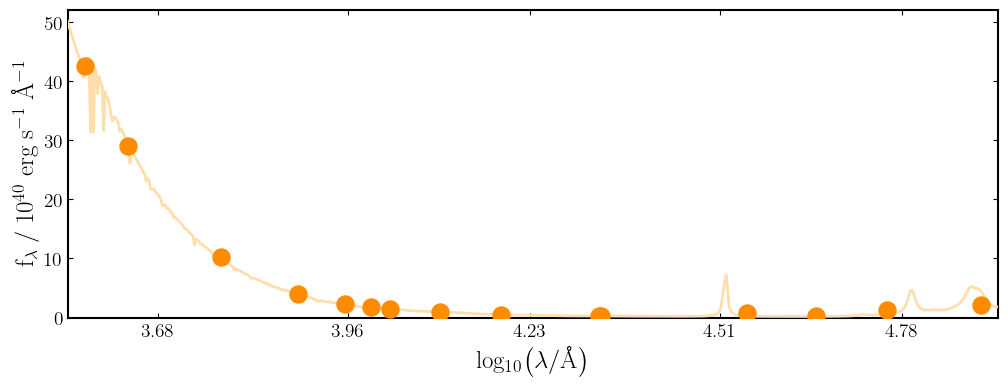

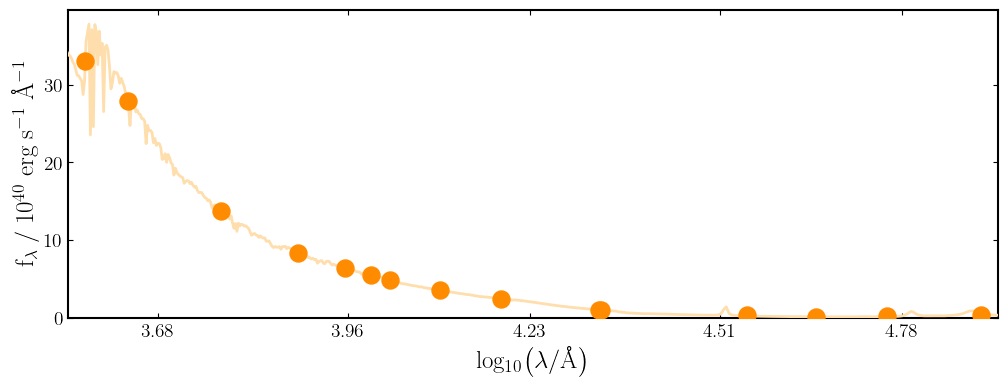

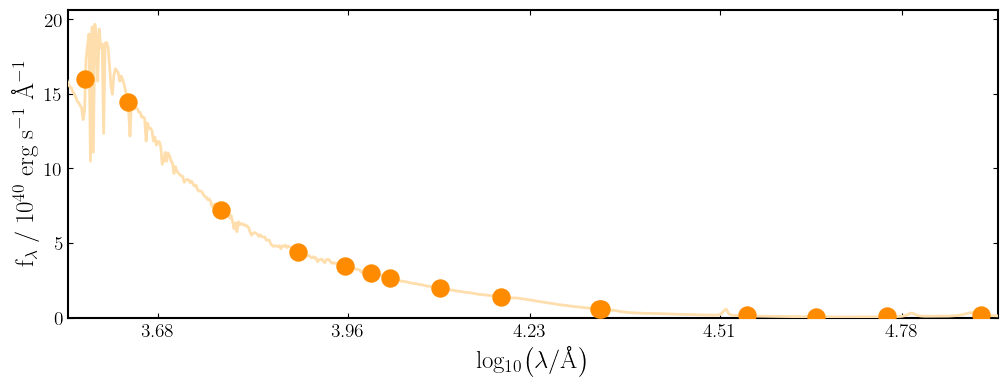

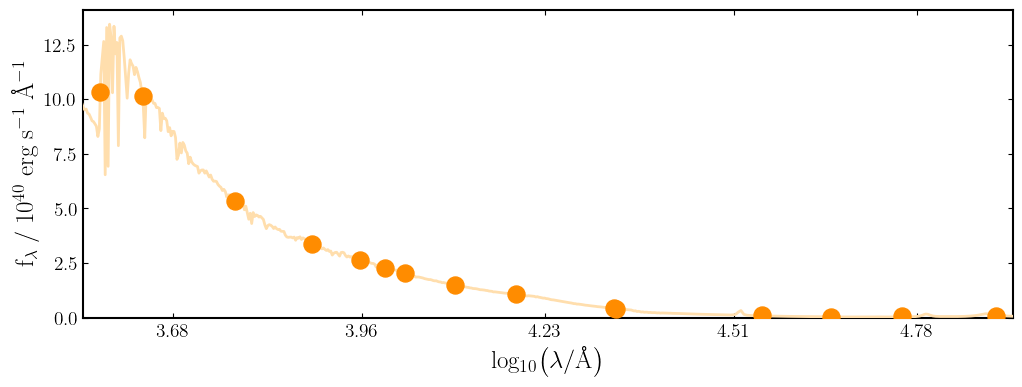

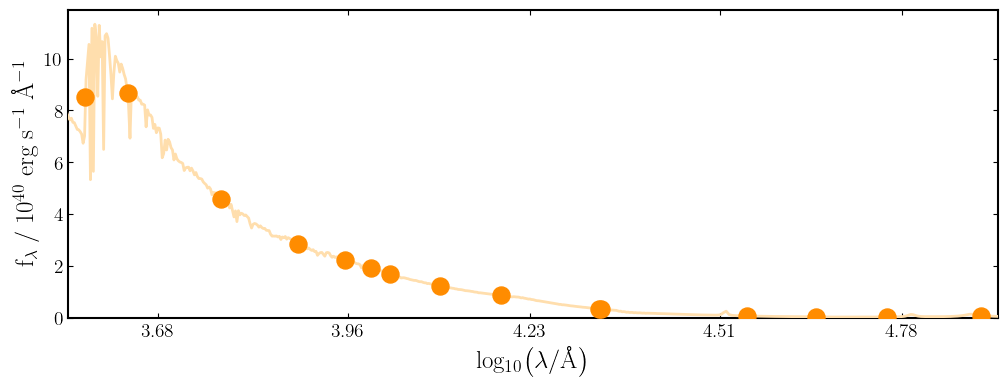

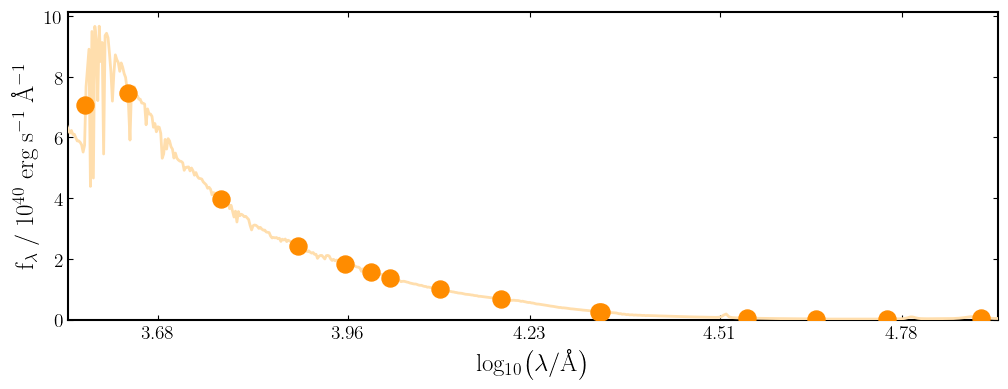

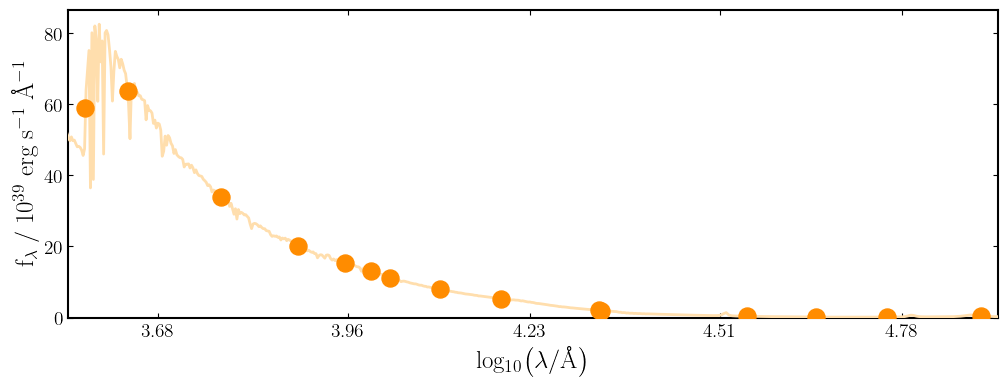

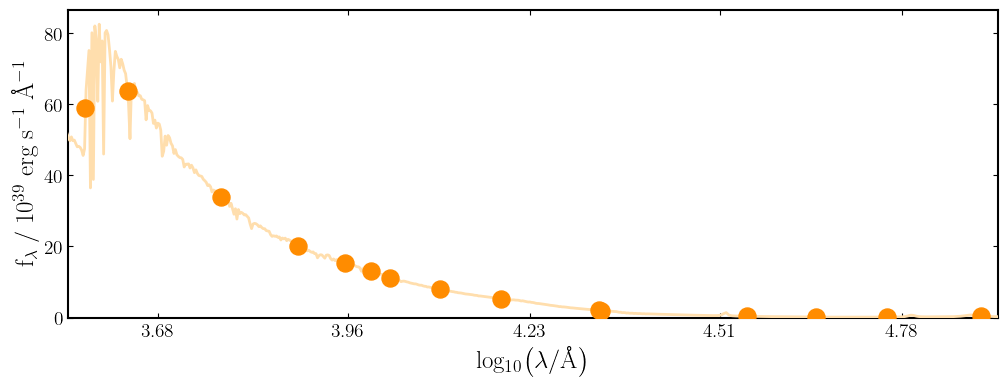

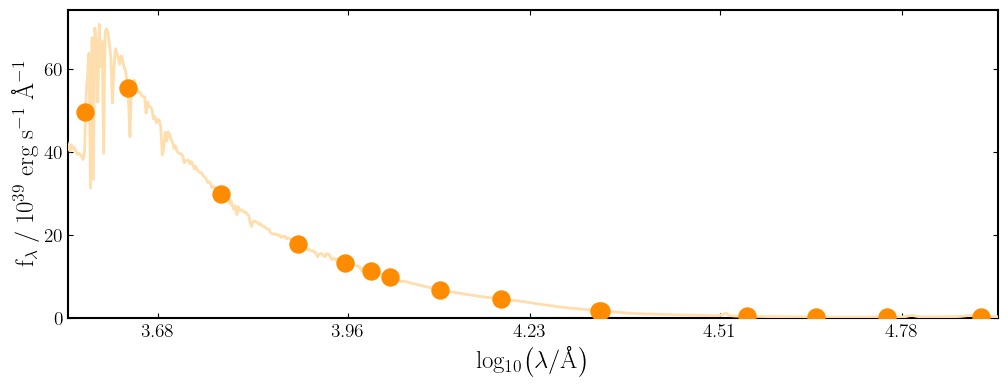

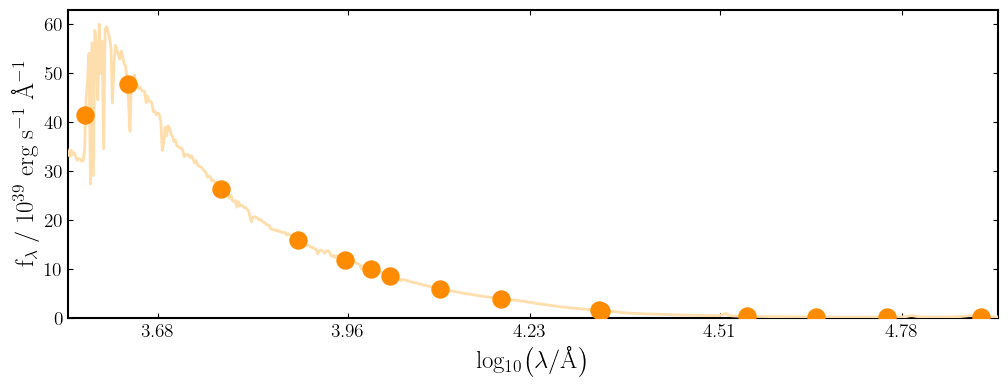

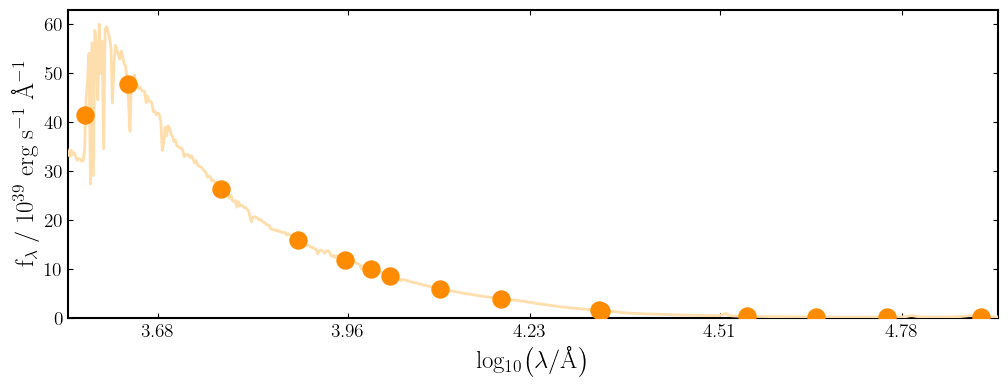

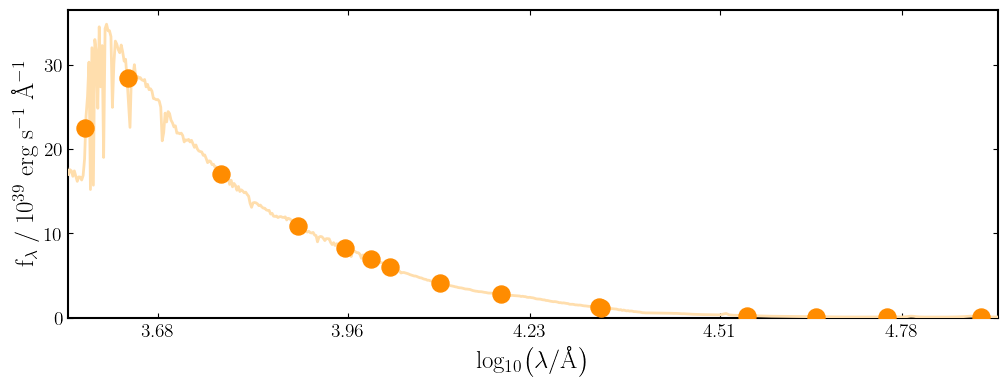

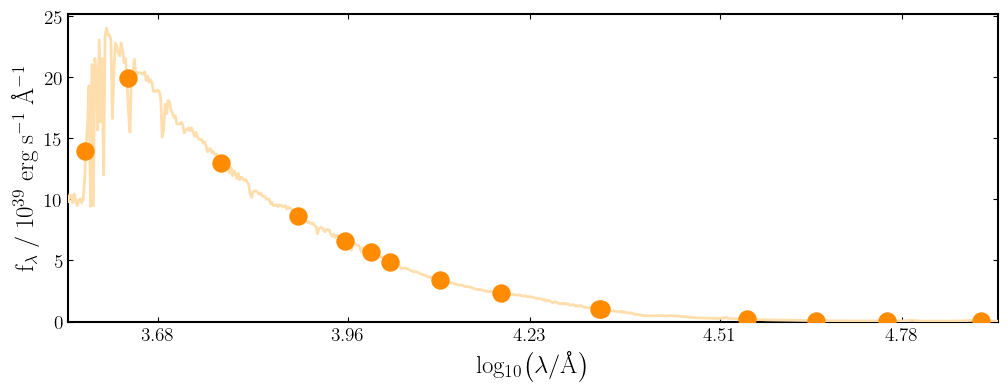

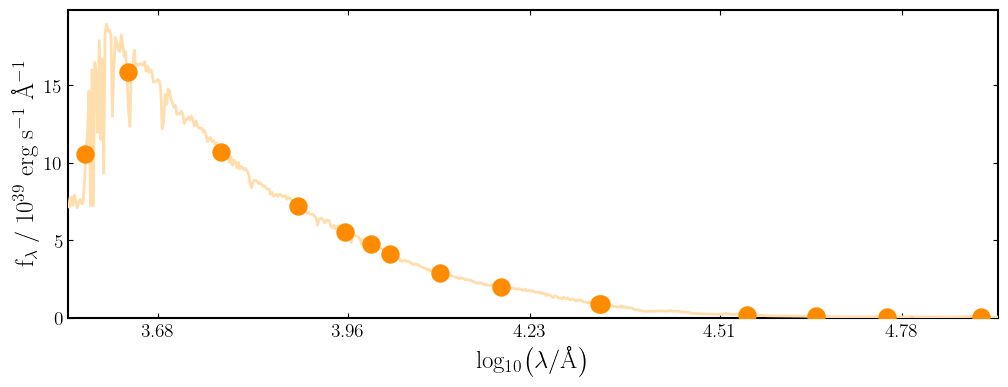

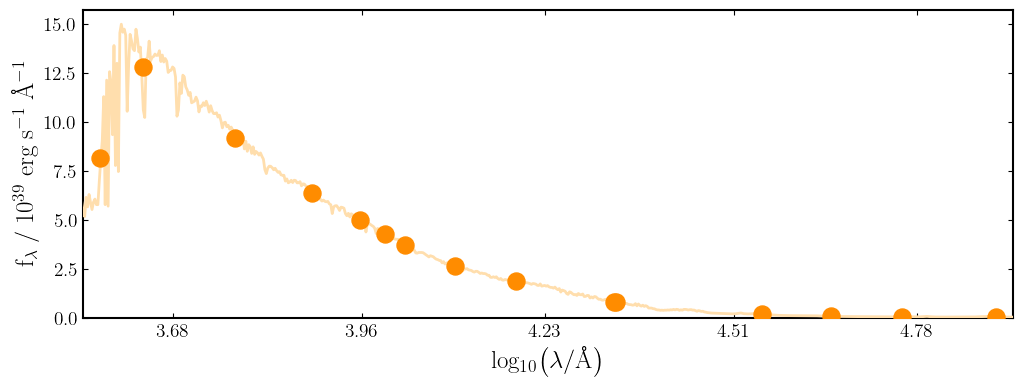

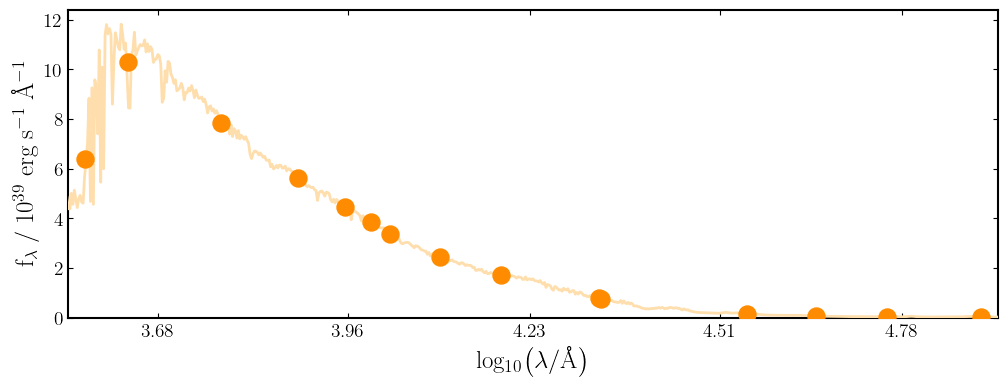

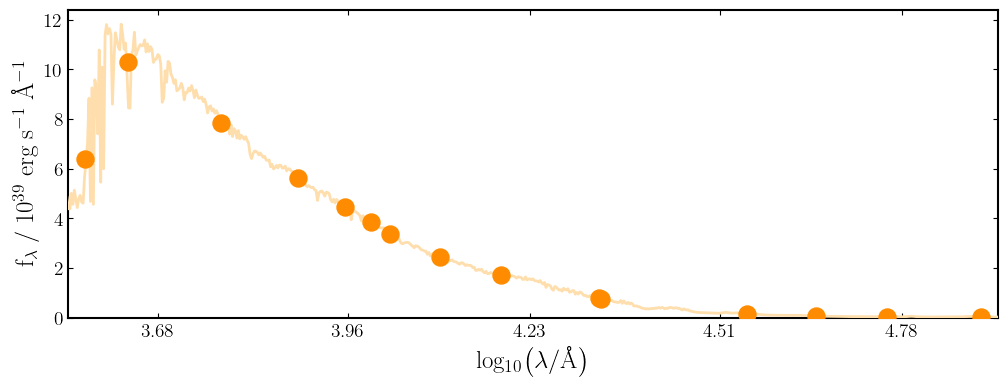

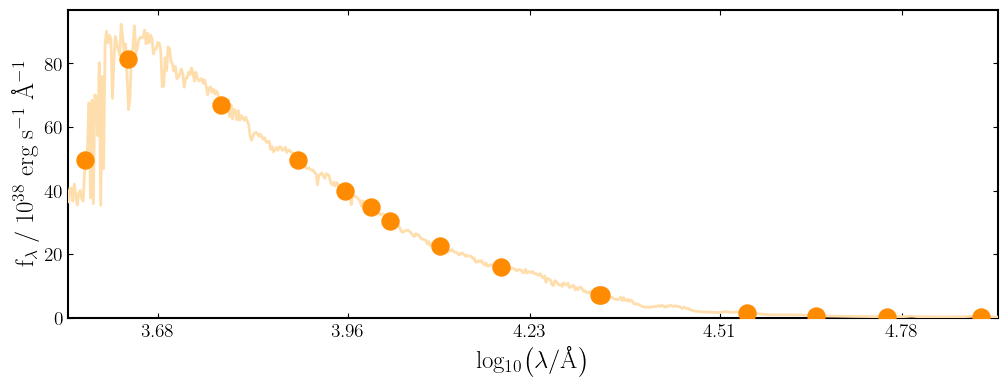

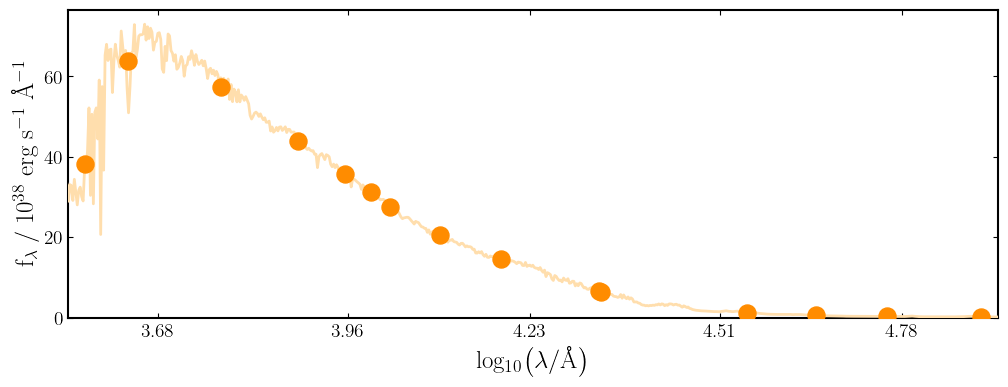

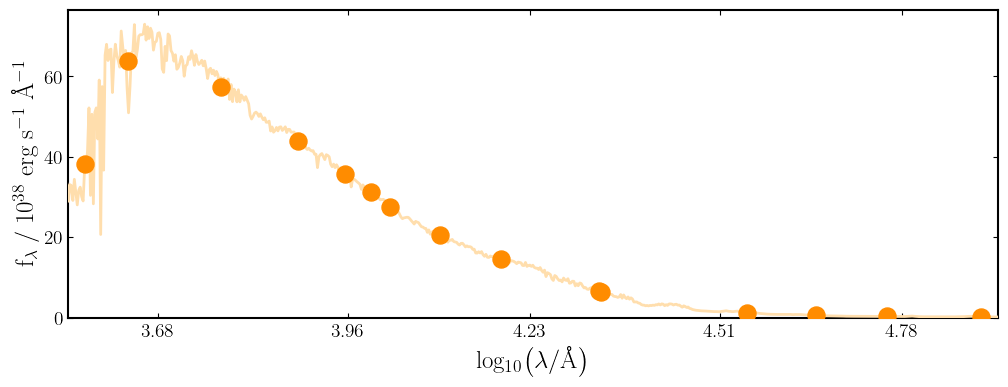

In [5]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt 

years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

dust = {}                         # Dust component
dust["type"] = "Calzetti"         # Define the shape of the attenuation curve
dust["Av"] = 0.2 

model_components = {}                   # The model components dictionary
model_components["redshift"] = 0      # Observed redshift     
model_components["dust"] = dust

for t in years:

    burst = {}                          # Tau model star formation history component
    burst["age"] = t/1000                   # Gyr
    burst["massformed"] = 10            # log_10(M*/M_solar)
    burst["metallicity"] = 0.5         # Z/Z_oldsolar
    model_components["burst"] = burst

    model = pipes.model_galaxy(model_components, filt_list=goodss_filt_list)

    fig = model.plot()


##log-linear plots for 1000 to 30000 angstroms on the same plot - with 1Gyr > t > 0Myr

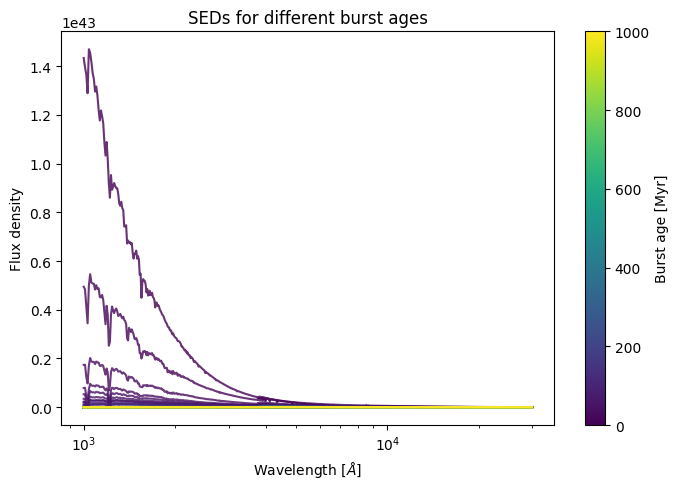

In [15]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Define burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust and model setup
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Setup figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # convert Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }

    model_components["burst"] = burst

    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(1000., 30000., 10.)
    )

    ax.plot(
        model.spec_wavs,
        model.spectrum,
        color=cmap(norm(t)),
        alpha=0.8
    )

# Log scale wavelength
ax.set_xscale("log")

# Labels, title, colorbar
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"Flux density")
ax.set_title("SEDs for different burst ages")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


##log-linear plots for 100 to 50000 angstroms on the same plot - with 1Gyr > t > 0Myr

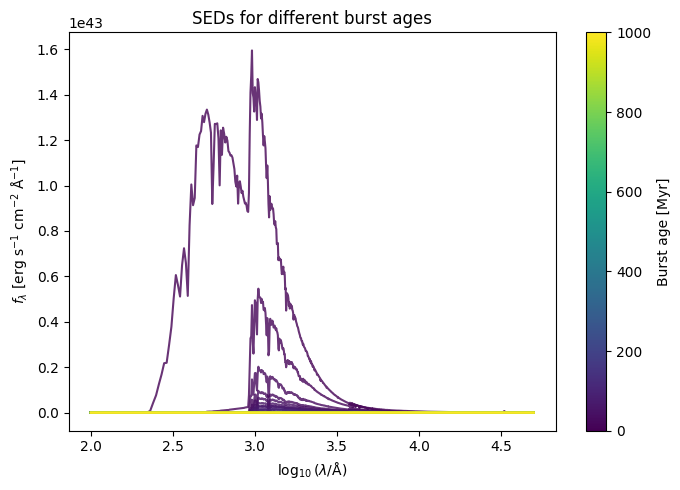

In [17]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in erg s^-1 cm^-2 A^-1 (default)
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 50000., 10.)
    )

    ax.plot(
        np.log10(model.spec_wavs),  # log10(lambda / Å)
        model.spectrum,             # f_lambda [erg s^-1 cm^-2 Å^-1]
        color=cmap(norm(t)),
        alpha=0.8
    )

# Labels & title
ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


##log-log plots for 100 to 50000 angstroms on the same plot - with 1Gyr > t > 0Myr

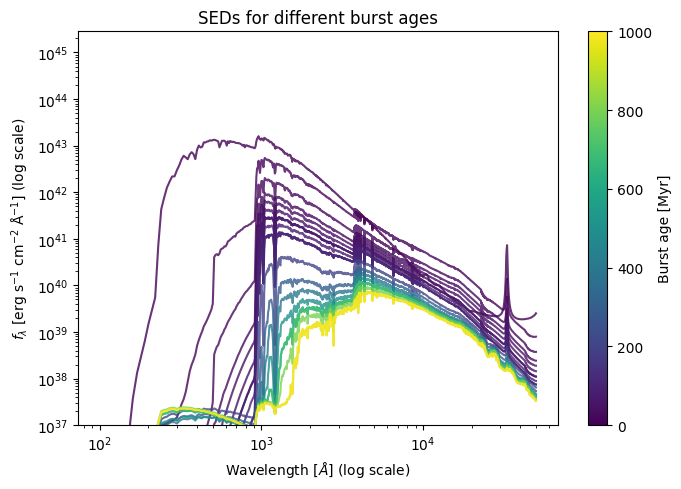

In [18]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 50000., 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e37)


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


##log-linear plots for 100 to 50000 angstroms on different plots (different axes) - with 1Gyr > t > 0Myr

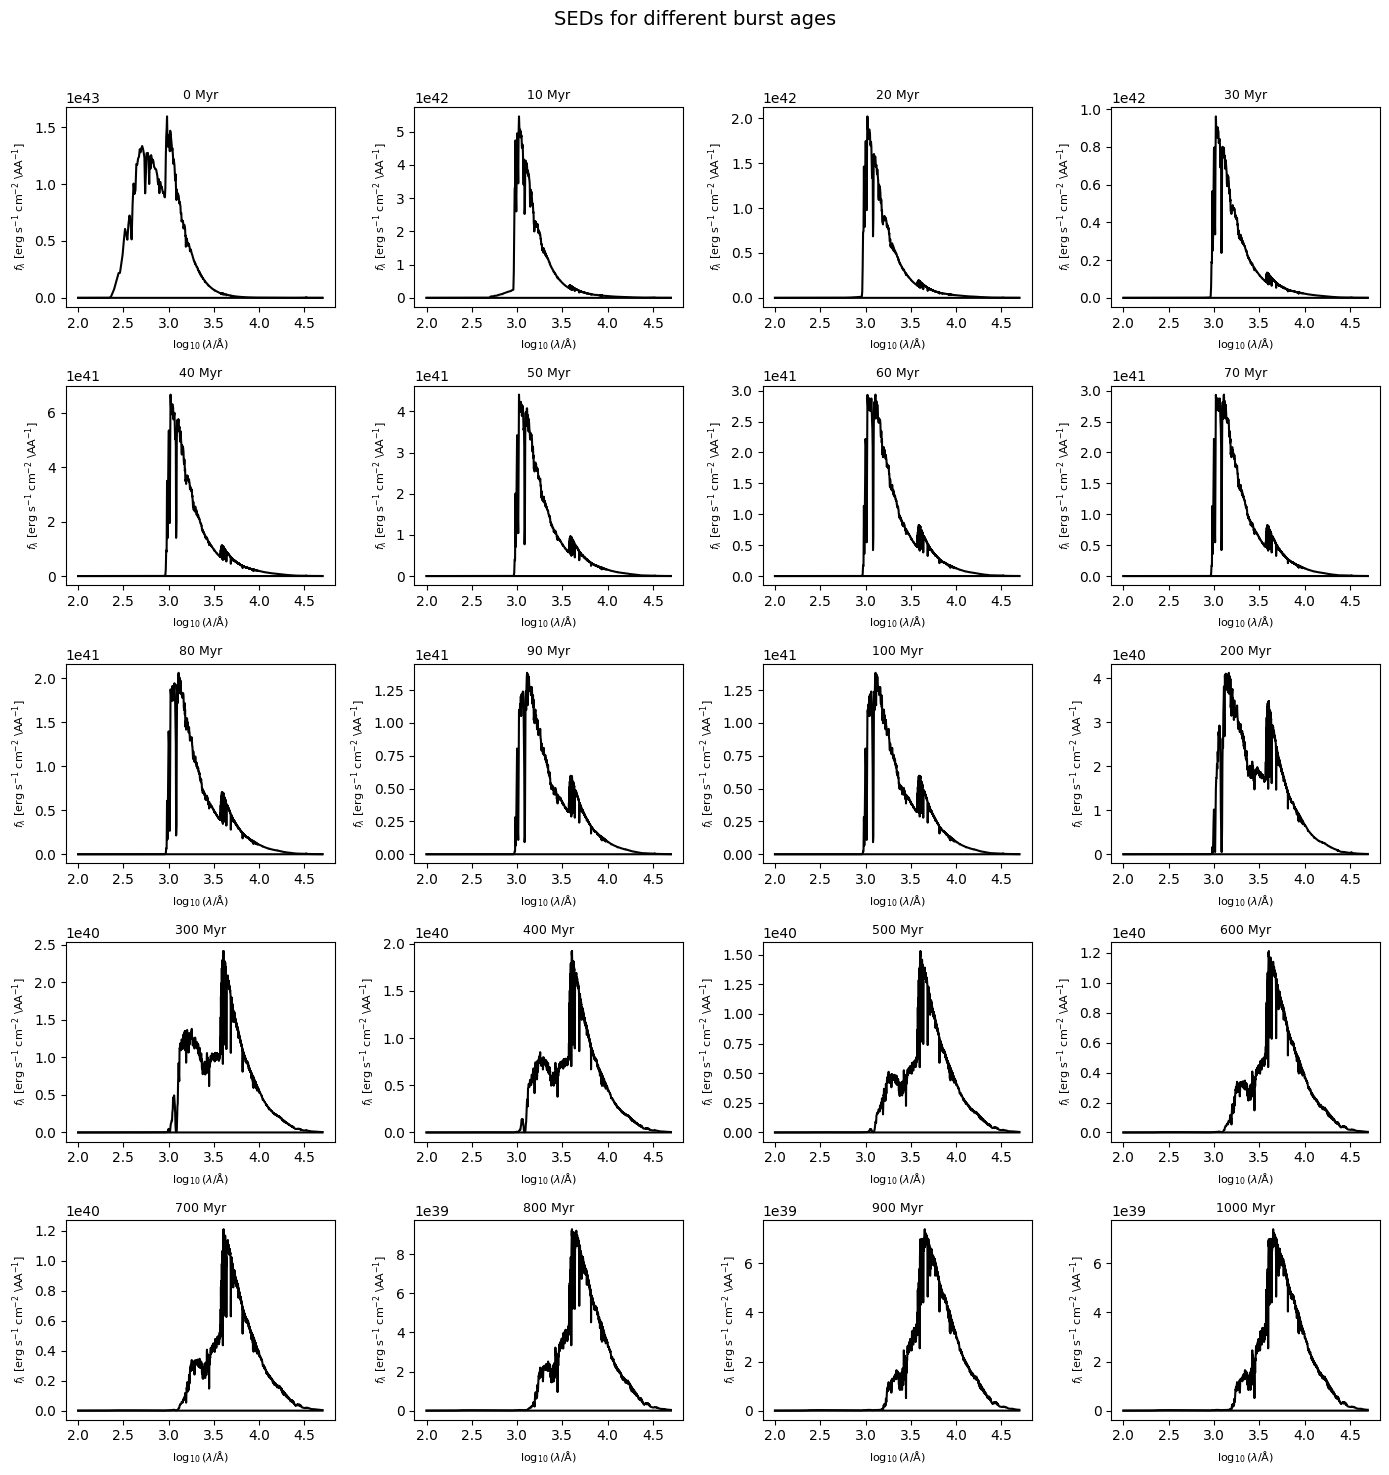

In [19]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model components
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {"redshift": 0, "dust": dust}


# Grid setup
n = len(years)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows), sharex=False, sharey=False)
axes = axes.flatten()

for i, t in enumerate(years):
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Generate model SED
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 50000., 10.),
    )

    ax = axes[i]
    ax.plot(np.log10(model.spec_wavs), model.spectrum, color="black")
    ax.set_title(f"{t} Myr", fontsize=9)
    ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$", fontsize=8)
    ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ \AA$^{-1}$]", fontsize=8)

# Turn off any extra axes
for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("SEDs for different burst ages", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##log-linear plots for 100 to 50000 angstroms on the same plot - with 10Myr > t > 0Myr

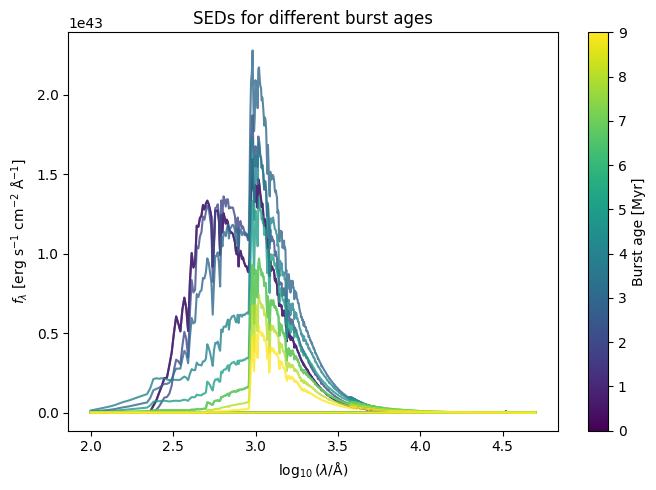

In [20]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 10, 1)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in erg s^-1 cm^-2 A^-1 (default)
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 50000., 10.)
    )

    ax.plot(
        np.log10(model.spec_wavs),  # log10(lambda / Å)
        model.spectrum,             # f_lambda [erg s^-1 cm^-2 Å^-1]
        color=cmap(norm(t)),
        alpha=0.8
    )

# Labels & title
ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


##log-linear plots for 100 to 50000 angstroms on the different plots - with 10Myr > t > 0Myr

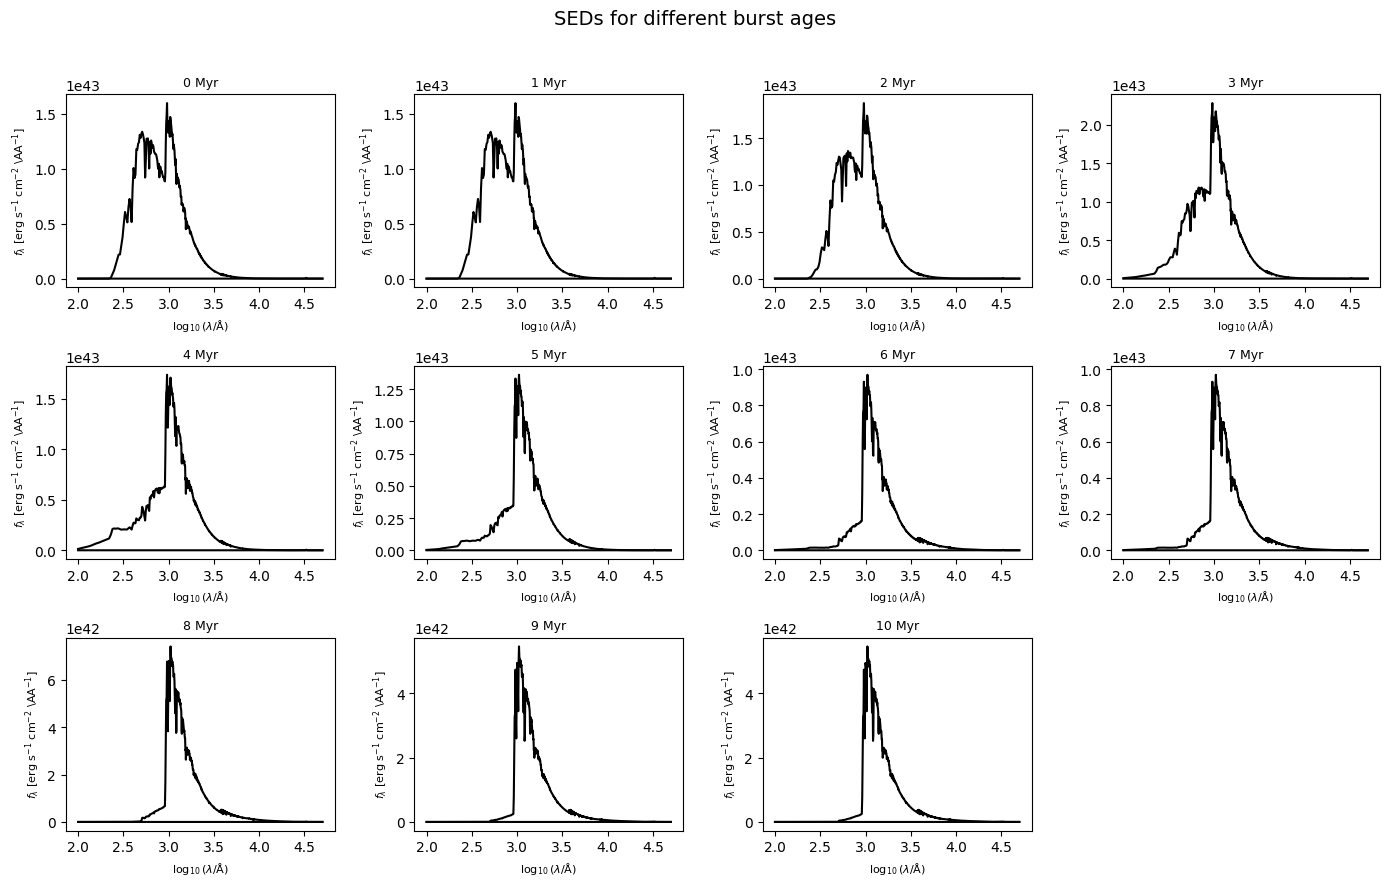

In [25]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 11, 1),
])

# Dust & model components
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {"redshift": 0, "dust": dust}

# Grid setup
n = len(years)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows), sharex=False, sharey=False)
axes = axes.flatten()

for i, t in enumerate(years):
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Generate model SED
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 50000., 10.),
    )

    ax = axes[i]
    ax.plot(np.log10(model.spec_wavs), model.spectrum, color="black")
    ax.set_title(f"{t} Myr", fontsize=9)
    ax.set_xlabel(r"$\log_{10}(\lambda / \mathrm{\AA})$", fontsize=8)
    ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ \AA$^{-1}$]", fontsize=8)

# Turn off any extra axes
for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("SEDs for different burst ages", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##log-log plots for full spectra - with 1Gyr > t > 0Myr

In [ ]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt 

years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

dust = {}                         # Dust component
dust["type"] = "Calzetti"         # Define the shape of the attenuation curve
dust["Av"] = 0.2 

model_components = {}                   # The model components dictionary
model_components["redshift"] = 0      # Observed redshift     
model_components["dust"] = dust

for t in years:
    burst = {}                          # Tau model star formation history component
    burst["age"] = t/1000                   # Gyr
    burst["massformed"] = 10            # log_10(M*/M_solar)
    burst["metallicity"] = 0.5         # Z/Z_oldsolar
    model_components["burst"] = burst
    model = pipes.model_galaxy(model_components, filt_list=goodss_filt_list)

    #model.plot_full_spectrum()

0
10
20
30
40
50
60
70
80
90
100
200
300
400
500
600
700
800
900
1000


##full spectrum plots for 100 to 5000000 angstroms on the same plot - with 1Gyr > t > 0Myr

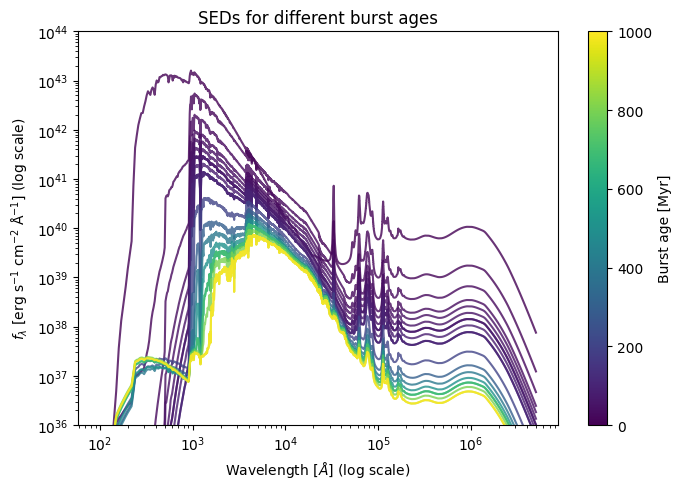

In [30]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 5000000., 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e36)
ax.set_ylim(top=1e44)


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


##full spectrum plots for 100 to 5000000 angstroms on the same plot - with 10Myr > t > 0Myr

D:\temp\ipykernel_10932\2193143331.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
D:\temp\ipykernel_10932\2193143331.py:63: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


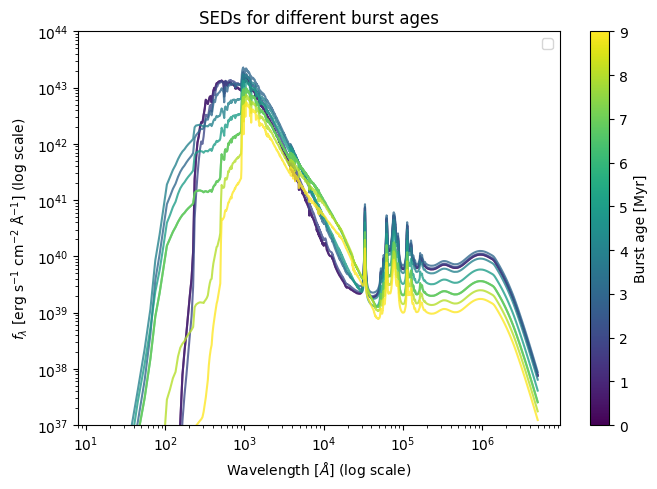

In [31]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 10, 1)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(15., 5000000., 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e37)
ax.set_ylim(top=1e44)
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


##full spectrum plots for 100 to 5000000 angstroms on different plots - with 1Gyr > t > 0Myr

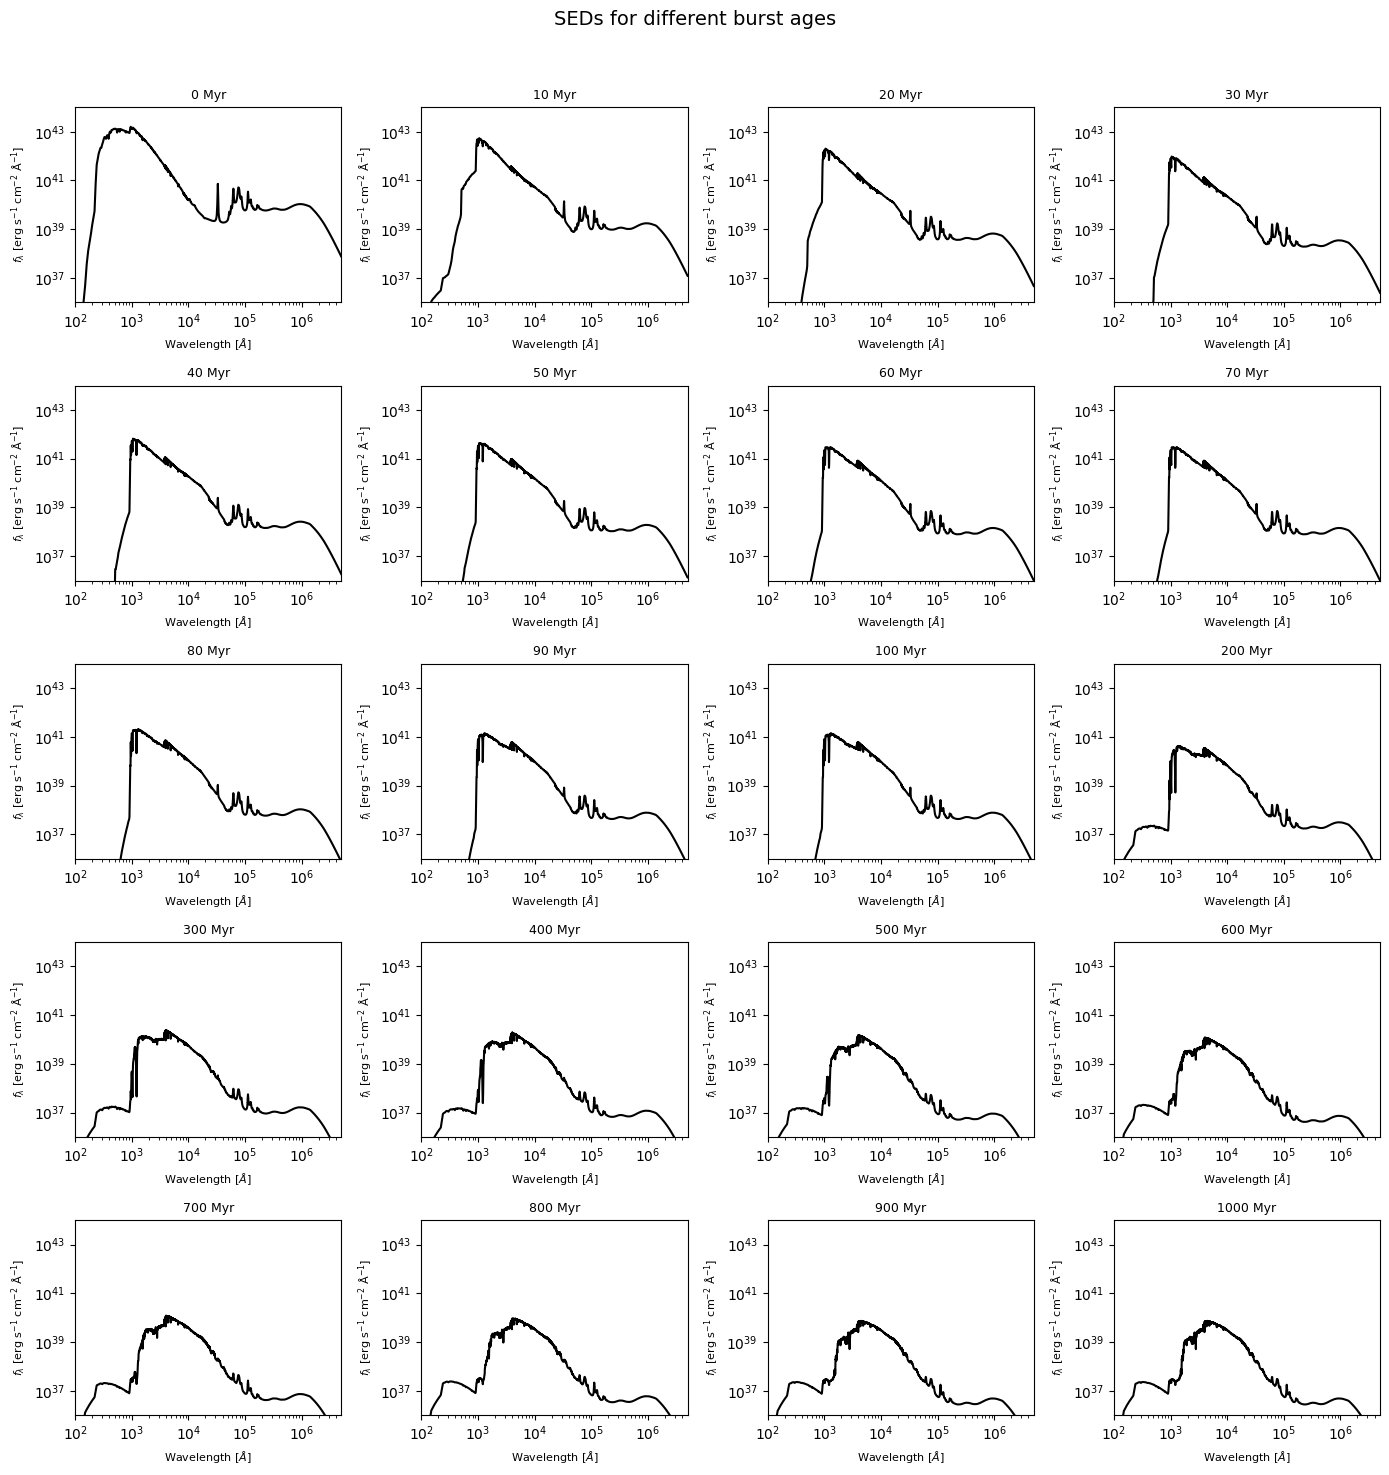

In [32]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

dust = {"type": "Calzetti", "Av": 0.2}
model_components = {"redshift": 0, "dust": dust}

# Precompute spectra + track global limits
all_specs = []
all_wavs = None

for t in years:
    burst = {
        "age": t / 1000,
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100., 5000000., 10.)
    )

    if all_wavs is None:
        all_wavs = model.spec_wavs

    all_specs.append(model.spectrum)

all_specs = np.array(all_specs)

# Global axis limits
xmin = all_wavs.min()
xmax = all_wavs.max()
ymin = 1e36
ymax = 1e44   # same range you used before

# Grid setup
n = len(years)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows))
axes = axes.flatten()

# Plot each panel
for i, t in enumerate(years):
    ax = axes[i]

    ax.plot(all_wavs, all_specs[i], color="black")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f"{t} Myr", fontsize=9)
    ax.set_xlabel(r"Wavelength [$\AA$]", fontsize=8)
    ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]", fontsize=8)

# Turn off unused panels
for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("SEDs for different burst ages", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##full spectrum plots for 100 to 5000000 angstroms on different plots - with 1Gyr > t > 0Myr

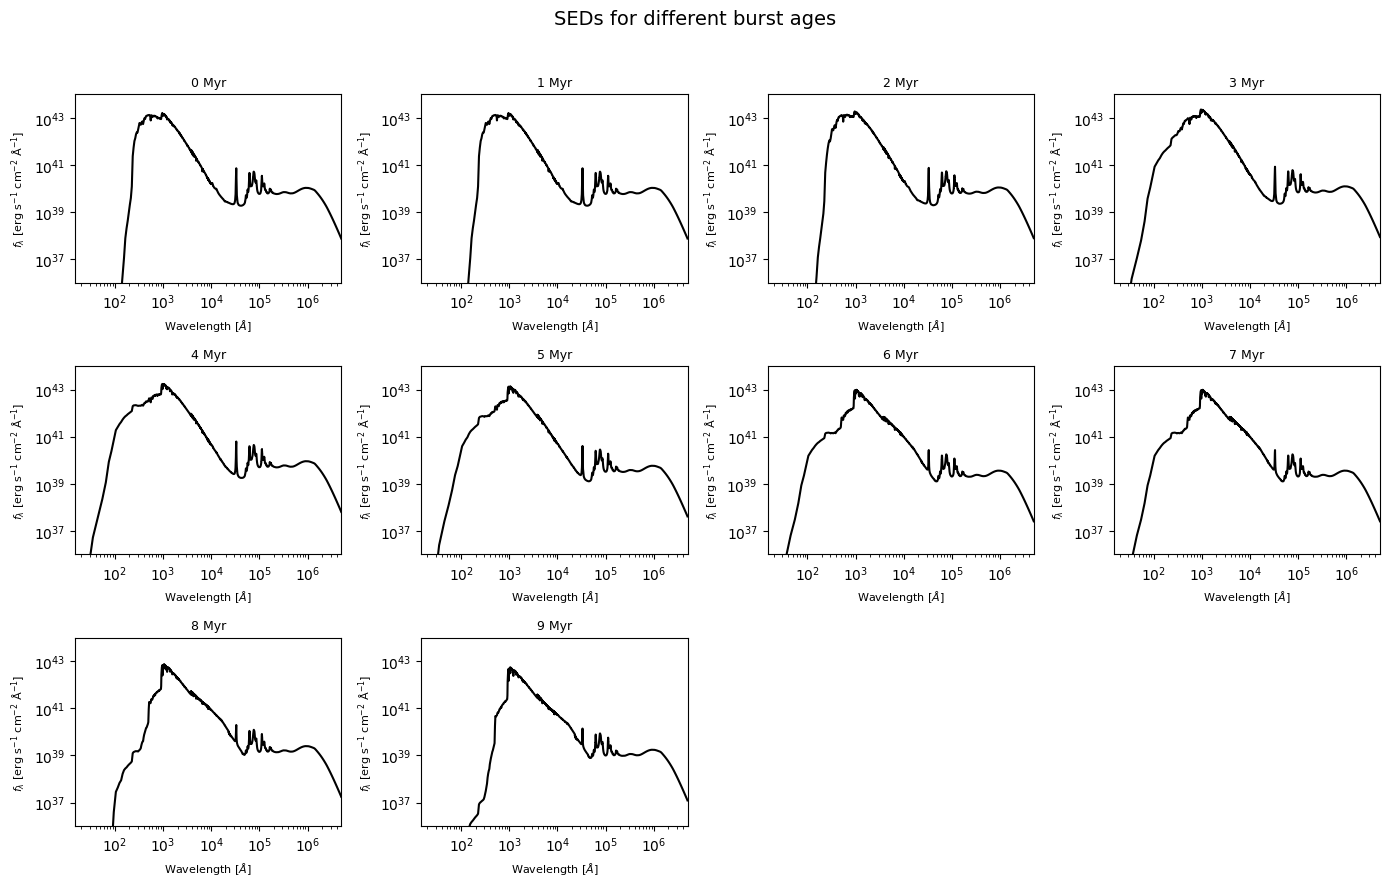

In [33]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 10, 1)
])

dust = {"type": "Calzetti", "Av": 0.2}
model_components = {"redshift": 0, "dust": dust}

# Precompute spectra + track global limits
all_specs = []
all_wavs = None

for t in years:
    burst = {
        "age": t / 1000,
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(15., 5000000., 10.)
    )

    if all_wavs is None:
        all_wavs = model.spec_wavs

    all_specs.append(model.spectrum)

all_specs = np.array(all_specs)

# Global axis limits
xmin = all_wavs.min()
xmax = all_wavs.max()
ymin = 1e36
ymax = 1e44   # same range you used before

# Grid setup
n = len(years)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3*nrows))
axes = axes.flatten()

# Plot each panel
for i, t in enumerate(years):
    ax = axes[i]

    ax.plot(all_wavs, all_specs[i], color="black")

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    ax.set_title(f"{t} Myr", fontsize=9)
    ax.set_xlabel(r"Wavelength [$\AA$]", fontsize=8)
    ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]", fontsize=8)

# Turn off unused panels
for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("SEDs for different burst ages", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##full spectrum plots - checking for balmer lines

D:\temp\ipykernel_10932\3146181980.py:69: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


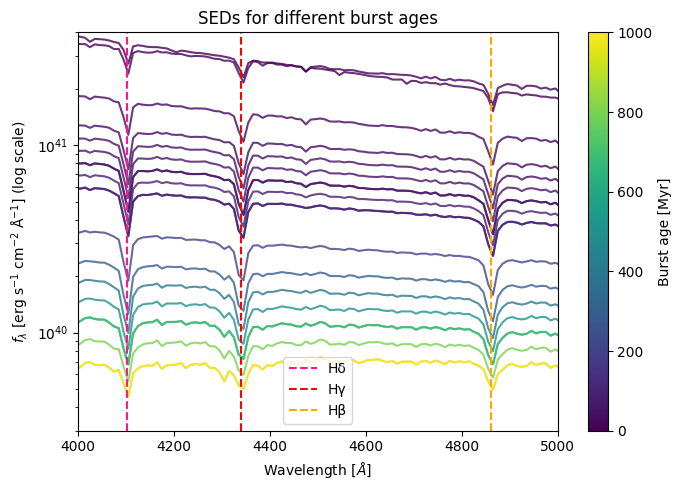

In [34]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])


# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(15., 5000000., 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=3e39)
ax.set_ylim(top=4e41)
ax.set_xlim(left=4000) # Set left limit to 10 Å
ax.set_xlim(right=5000)
ax.vlines(4101.734, color = "deeppink", linestyle="--", ymax=4e41, ymin=3e39, label="Hδ")
ax.vlines(4340.472, color = "red", linestyle="--", ymax=4e41, ymin=3e39, label="Hγ")
ax.vlines(4861.35, color = "orange", linestyle="--", ymax=4e41, ymin=3e39, label="Hβ")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## full spectrum - searching for H-alpha and OII lines

###H-alpha

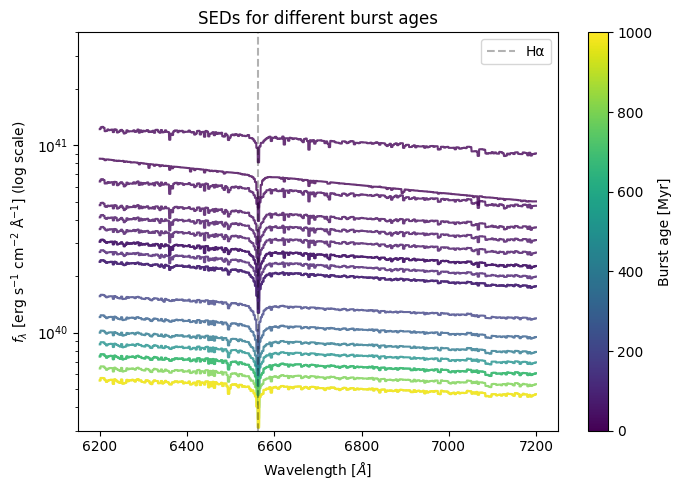

In [35]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])


# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(6200, 7200., 0.1)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=3e39)
ax.set_ylim(top=4e41)
ax.vlines(6562.79, color = "black", linestyle="--", ymax=4e41, ymin=3e39, label="Hα", alpha=0.3)
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


### OII

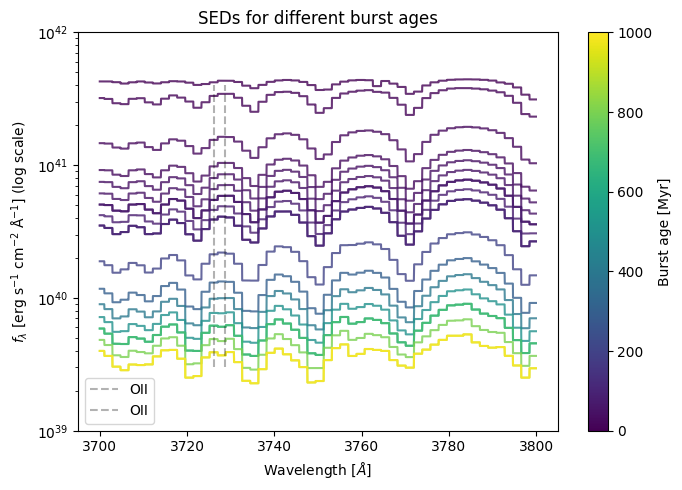

In [36]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])


# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(3700, 3800., 0.01)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=1e39)
ax.set_ylim(top=1e42)
ax.vlines(3726.1, color = "black", linestyle="--", ymax=4e41, ymin=3e39, label="OII", alpha=0.3)
ax.vlines(3728.8, color = "black", linestyle="--", ymax=4e41, ymin=3e39, label="OII", alpha=0.3)
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## OII in young galaxies

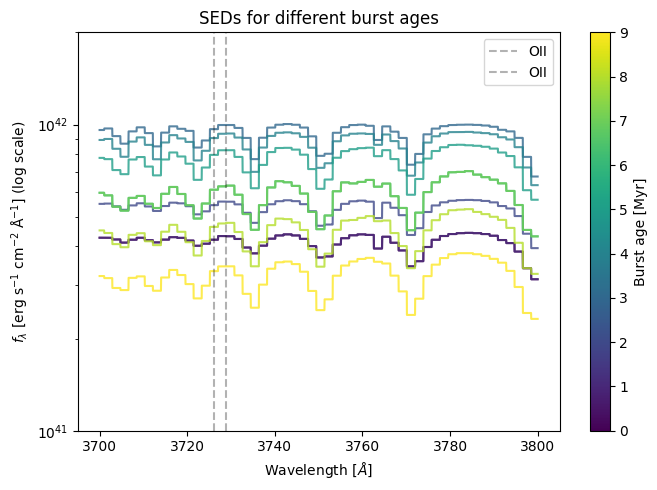

In [37]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 10, 1),
])


# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(3700, 3800., 0.01)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=1e41)
ax.set_ylim(top=2e42)
ax.vlines(3726.1, color = "black", linestyle="--", ymax=2e42, ymin=1e41, label="OII", alpha=0.3)
ax.vlines(3728.8, color = "black", linestyle="--", ymax=2e42, ymin=1e41, label="OII", alpha=0.3)
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

## finding exact wavelength of peaks in spectra

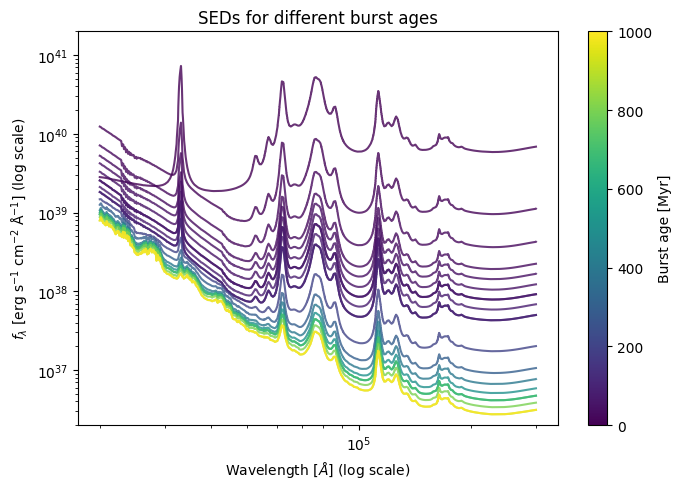

In [38]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(2e4, 3e5, 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=2e36)
ax.set_ylim(top=2e41)


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


### peak 3

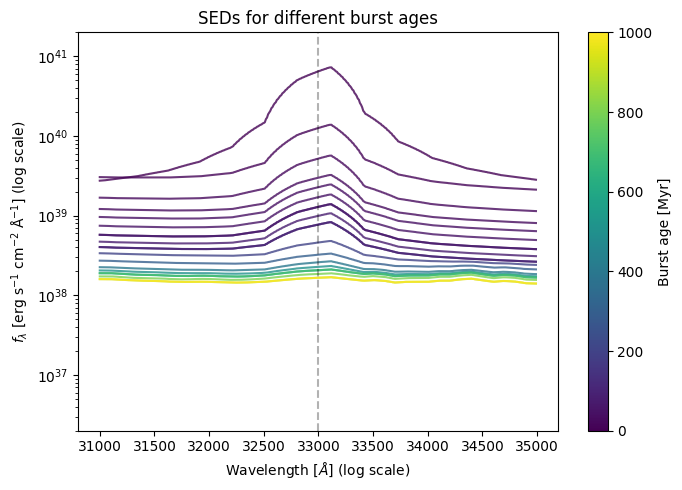

In [39]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(31000,35000 , 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=2e36)
ax.set_ylim(top=2e41)
ax.vlines(33000, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3)


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


### peak 4

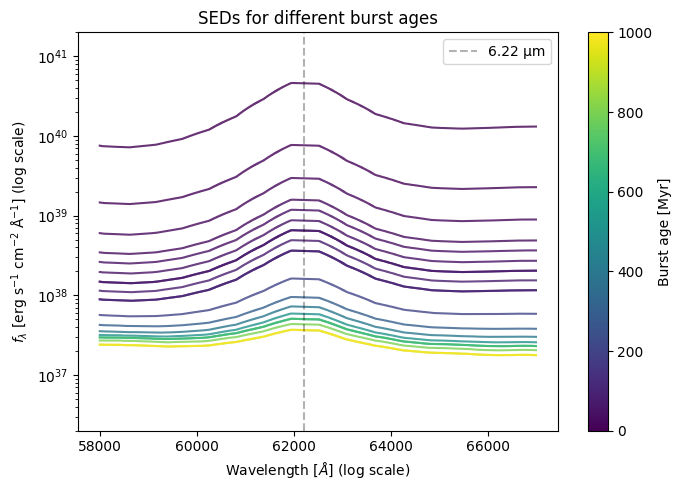

In [40]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(58000,67000 , 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=2e36)
ax.set_ylim(top=2e41)
wavelength = 62200
ax.vlines(wavelength, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength/10000) + " μm")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## peak(s) 5

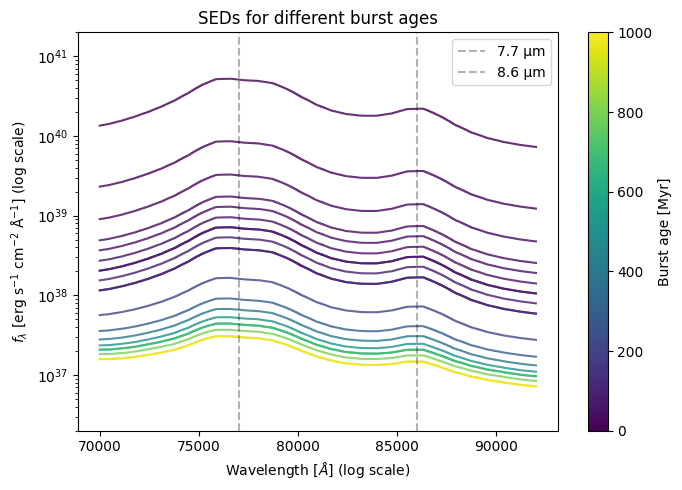

In [41]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(70000,92000 , 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=2e36)
ax.set_ylim(top=2e41)
wavelength1 = 77000
wavelength2 = 86000
ax.vlines(wavelength1, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength1/10000) + " μm")
ax.vlines(wavelength2, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength2/10000) + " μm")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## peak 6

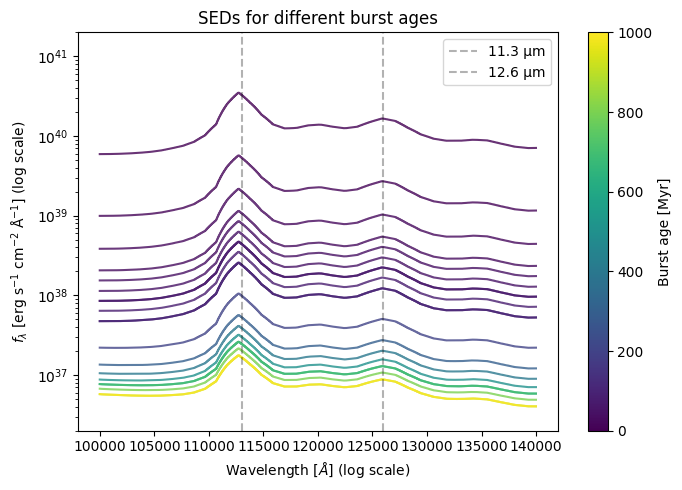

In [42]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(100000,140000 , 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=2e36)
ax.set_ylim(top=2e41)
wavelength1 = 113000
wavelength2 = 126000
ax.vlines(wavelength1, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength1/10000) + " μm")
ax.vlines(wavelength2, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength2/10000) + " μm")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## line 7

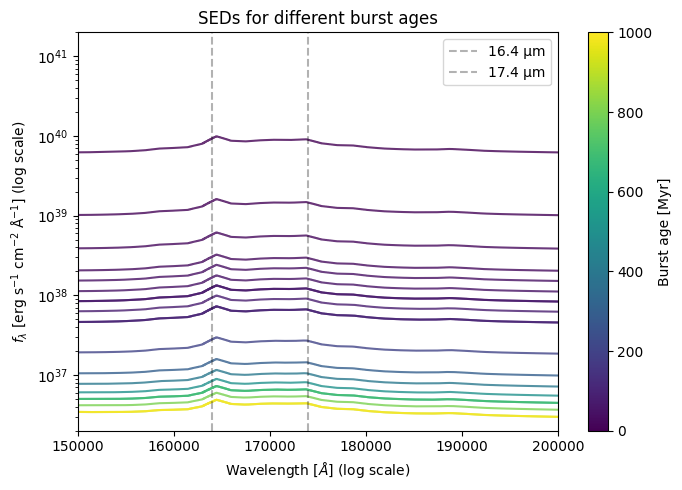

In [43]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}


# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(150000,200000 , 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=2e36)
ax.set_ylim(top=2e41)
ax.set_xlim(left=150000)
ax.set_xlim(right=200000)
wavelength1 = 164000
wavelength2 = 174000
ax.vlines(wavelength1, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength1/10000) + " μm")
ax.vlines(wavelength2, color = "black", linestyle="--", ymax=4e41, ymin=2e36, alpha=0.3, label= str(wavelength2/10000) + " μm")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## balmer break

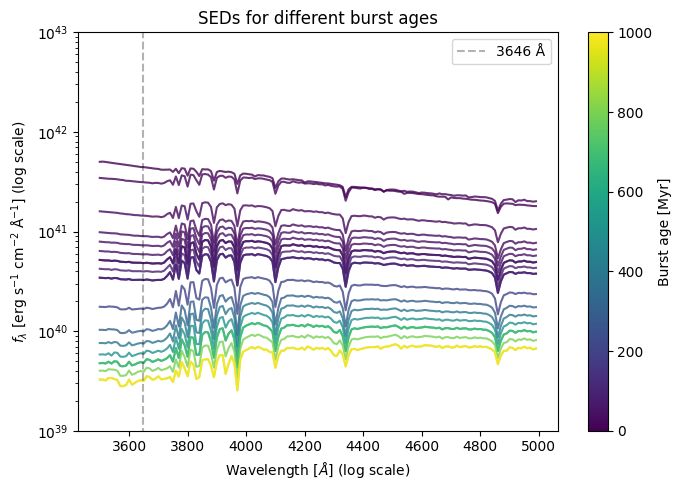

In [44]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(3500,5000 , 10.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=1e39)
ax.set_ylim(top=1e43)
wavelength1 = 3646
ax.vlines(wavelength1, color = "black", linestyle="--", ymax=1e43, ymin=2e36, alpha=0.3, label= str(wavelength1) + " Å")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


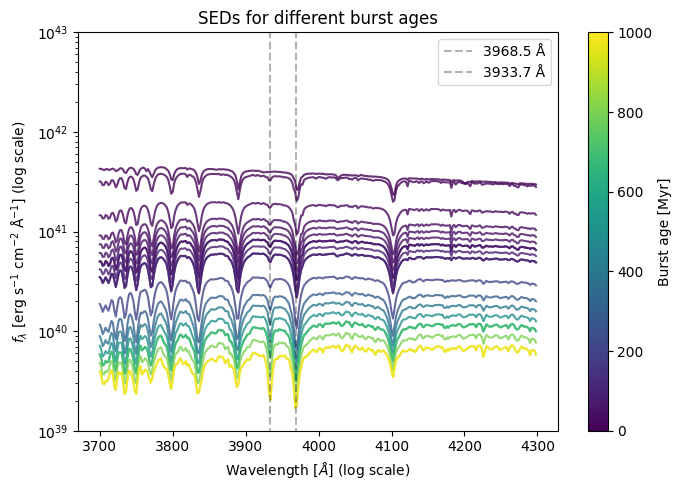

In [48]:
import bagpipes as pipes
import numpy as np
import matplotlib.pyplot as plt

# Burst ages in Myr
years = np.concatenate([
    np.arange(0, 100, 10),
    np.arange(100, 1001, 100)
])

# Dust & model
dust = {"type": "Calzetti", "Av": 0.2}
model_components = {
    "redshift": 0,
    "dust": dust
}

# Figure & colormap
fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

# Loop over burst ages
for t in years:
    burst = {
        "age": t / 1000,   # Myr -> Gyr
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    # Create the model galaxy, get spectrum in default units
    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(3700,4300 , 2.)
    )

    ax.plot(
        model.spec_wavs,  # linear wavelength
        model.spectrum,   # f_lambda
        color=cmap(norm(t)),
        alpha=0.8
    )

# Set both axes to logarithmic scale
ax.set_yscale('log')
ax.set_ylim(bottom=1e39)
ax.set_ylim(top=1e43)
wavelength1 = 3968.5 #calcium II H line
wavelength2 = 3933.7 #calcium II K line
ax.vlines(wavelength1, color = "black", linestyle="--", ymax=1e43, ymin=2e36, alpha=0.3, label= str(wavelength1) + " Å")
ax.vlines(wavelength2, color = "black", linestyle="--", ymax=1e43, ymin=2e36, alpha=0.3, label= str(wavelength2) + " Å")
ax.legend()


# Labels & title
ax.set_xlabel(r"Wavelength [$\AA$] (log scale)")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$] (log scale)")
ax.set_title("SEDs for different burst ages")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()


## Analysing Linewidths

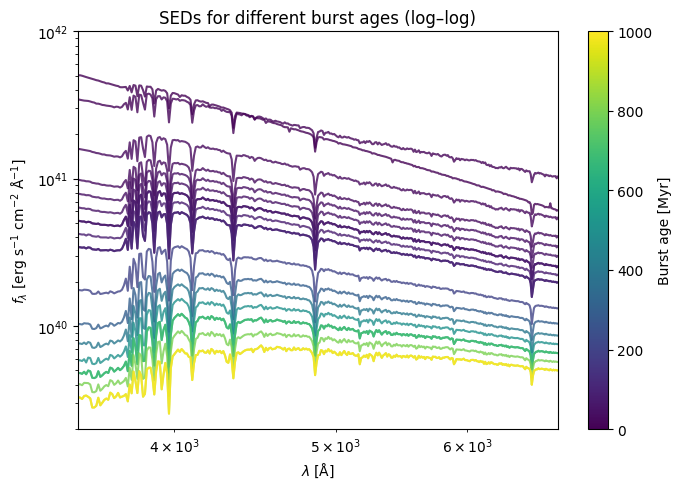

(4180, 2)

Spectral diagnostics:

Age = 0 Myr
  EW(Hδ)  = 3.13 Å
  EW(Hα)  = 1.53 Å
  D4000   = 0.91

Age = 10 Myr
  EW(Hδ)  = 3.92 Å
  EW(Hα)  = 1.17 Å
  D4000   = 0.96

Age = 20 Myr
  EW(Hδ)  = 5.39 Å
  EW(Hα)  = 1.52 Å
  D4000   = 0.98

Age = 30 Myr
  EW(Hδ)  = 6.35 Å
  EW(Hα)  = 1.67 Å
  D4000   = 1.01

Age = 40 Myr
  EW(Hδ)  = 6.66 Å
  EW(Hα)  = 1.73 Å
  D4000   = 1.02

Age = 50 Myr
  EW(Hδ)  = 6.92 Å
  EW(Hα)  = 1.79 Å
  D4000   = 1.03

Age = 60 Myr
  EW(Hδ)  = 7.15 Å
  EW(Hα)  = 1.86 Å
  D4000   = 1.04

Age = 70 Myr
  EW(Hδ)  = 7.15 Å
  EW(Hα)  = 1.86 Å
  D4000   = 1.04

Age = 80 Myr
  EW(Hδ)  = 7.37 Å
  EW(Hα)  = 1.92 Å
  D4000   = 1.05

Age = 90 Myr
  EW(Hδ)  = 7.42 Å
  EW(Hα)  = 1.96 Å
  D4000   = 1.07

Age = 100 Myr
  EW(Hδ)  = 7.42 Å
  EW(Hα)  = 1.96 Å
  D4000   = 1.07

Age = 200 Myr
  EW(Hδ)  = 7.81 Å
  EW(Hα)  = 1.99 Å
  D4000   = 1.11

Age = 300 Myr
  EW(Hδ)  = 8.45 Å
  EW(Hα)  = 1.99 Å
  D4000   = 1.17

Age = 400 Myr
  EW(Hδ)  = 8.61 Å
  EW(Hα)  = 2.00 Å
  D4000   = 1.2

In [49]:
import numpy as np
import matplotlib.pyplot as plt

#spectral diagnostic functions
def equivalent_width(wave, flux, line_region, blue_cont, red_cont):

    line_mask = (wave > line_region[0]) & (wave < line_region[1])
    blue_mask = (wave > blue_cont[0]) & (wave < blue_cont[1])
    red_mask  = (wave > red_cont[0]) & (wave < red_cont[1])

    cont_flux = np.mean(
        np.concatenate([flux[blue_mask], flux[red_mask]])
    )

    ew = np.trapz(1 - flux[line_mask] / cont_flux,
                  wave[line_mask])

    return ew


def d4000(wave, flux):

    blue = (wave > 3850.) & (wave < 3950.)
    red  = (wave > 4000.) & (wave < 4100.)

    return np.mean(flux[red]) / np.mean(flux[blue])

#Line windows
HDELTA_LINE = (4083., 4122.)
HDELTA_BLUE = (4041., 4079.)
HDELTA_RED  = (4128., 4161.)

HALPHA_LINE = (6553., 6573.)
HALPHA_BLUE = (6500., 6540.)
HALPHA_RED  = (6575., 6620.)

ew_hdelta_vals = []
ew_halpha_vals = []
d4000_vals = []

fig, ax = plt.subplots(figsize=(7,5))
cmap = plt.cm.viridis
norm = plt.Normalize(years.min(), years.max())

for t in years:

    burst = {
        "age": t / 1000,
        "massformed": 10,
        "metallicity": 0.5
    }
    model_components["burst"] = burst

    model = pipes.model_galaxy(
        model_components,
        filt_list=goodss_filt_list,
        spec_wavs=np.arange(200., 42000., 10.)
    )

    wave = model.spectrum[:, 0]
    flux = model.spectrum[:, 1]

    ew_hdelta = equivalent_width(
        wave, flux,
        HDELTA_LINE,
        HDELTA_BLUE,
        HDELTA_RED
    )

    ew_halpha = equivalent_width(
        wave, flux,
        HALPHA_LINE,
        HALPHA_BLUE,
        HALPHA_RED
    )

    d4 = d4000(wave, flux)

    ew_hdelta_vals.append(ew_hdelta)
    ew_halpha_vals.append(ew_halpha)
    d4000_vals.append(d4)

    ax.plot(
        wave,
        flux,
        color=cmap(norm(t)),
        alpha=0.8
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel(r"$\lambda \; [\mathrm{\AA}]$")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$]")
ax.set_ylim(2e39, 1e42)
ax.set_xlim(3.5e3, 6.8e3)
ax.set_title("SEDs for different burst ages (log–log)")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="Burst age [Myr]")

plt.tight_layout()
plt.show()

print(model.spectrum.shape)

print("\nSpectral diagnostics:\n")
for i, t in enumerate(years):
    print(f"Age = {t:.0f} Myr")
    print(f"  EW(Hδ)  = {ew_hdelta_vals[i]:.2f} Å")
    print(f"  EW(Hα)  = {ew_halpha_vals[i]:.2f} Å")
    print(f"  D4000   = {d4000_vals[i]:.2f}")
    print()

D:\temp\ipykernel_10932\3691751829.py:28: RuntimeWarning: divide by zero encountered in log10
  log_age = np.log10(age_myr[mask])


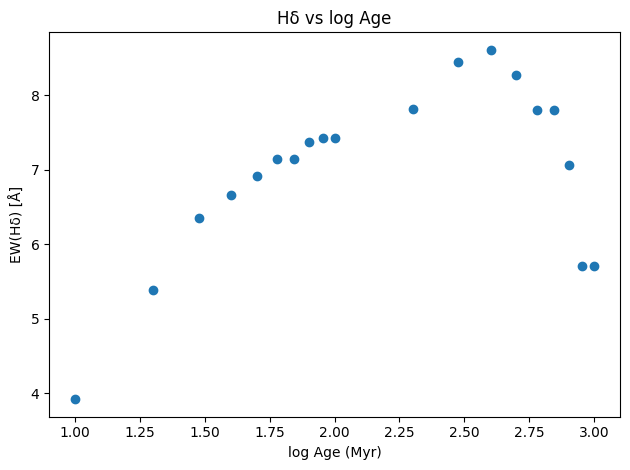

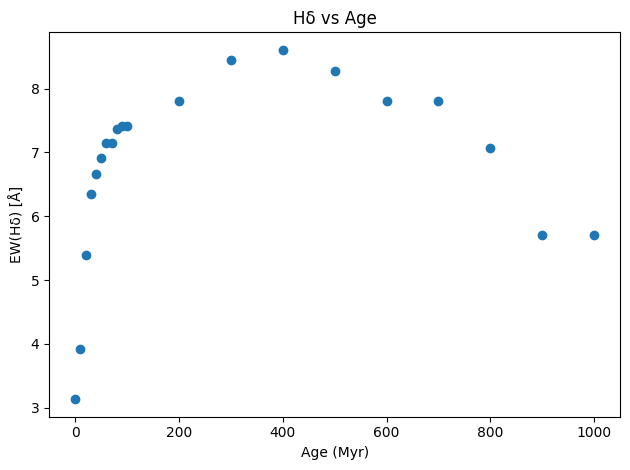

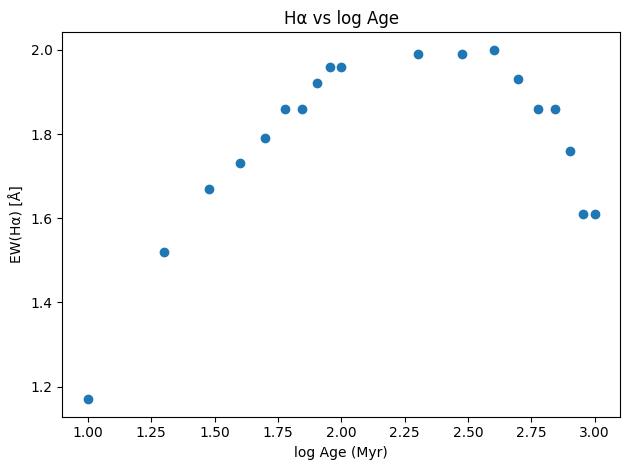

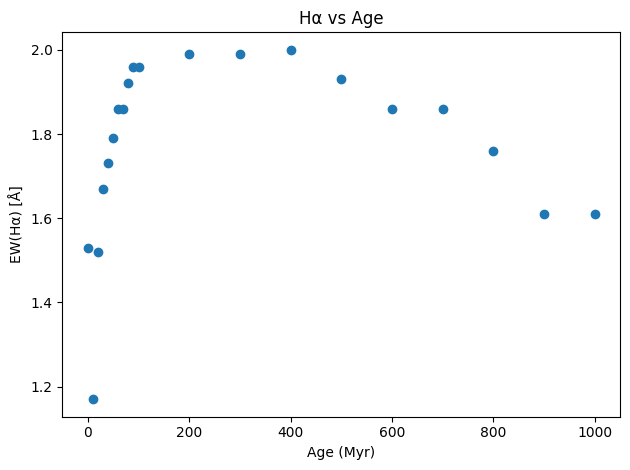

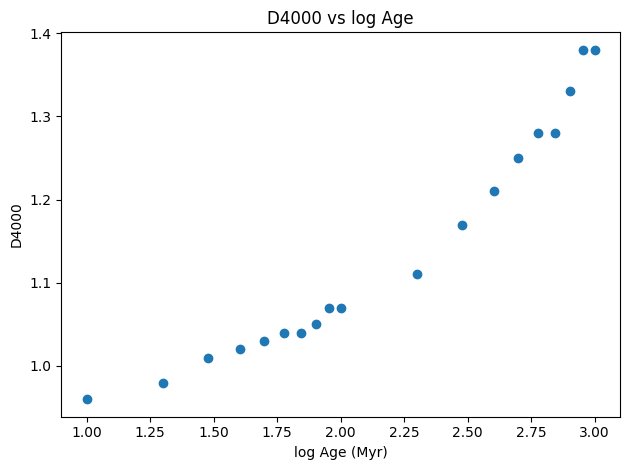

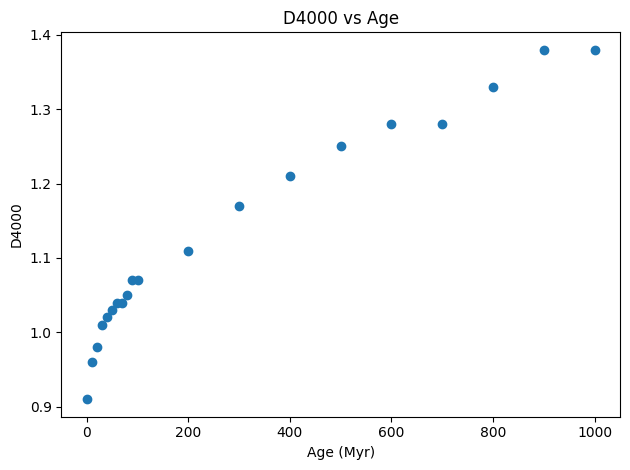

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# --- Arrays ---

age_myr = np.array([
    0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
    200, 300, 400, 500, 600, 700, 800, 900, 1000
])

ew_hdelta = np.array([
    3.13, 3.92, 5.39, 6.35, 6.66, 6.92, 7.15, 7.15, 7.37, 7.42, 7.42,
    7.81, 8.45, 8.61, 8.27, 7.80, 7.80, 7.07, 5.71, 5.71
])

ew_halpha = np.array([
    1.53, 1.17, 1.52, 1.67, 1.73, 1.79, 1.86, 1.86, 1.92, 1.96, 1.96,
    1.99, 1.99, 2.00, 1.93, 1.86, 1.86, 1.76, 1.61, 1.61
])

d4000 = np.array([
    0.91, 0.96, 0.98, 1.01, 1.02, 1.03, 1.04, 1.04, 1.05, 1.07, 1.07,
    1.11, 1.17, 1.21, 1.25, 1.28, 1.28, 1.33, 1.38, 1.38
])

# --- Remove age = 0 for log scale ---
mask = age_myr >= 0
log_age = np.log10(age_myr[mask])

# --- Plot EW(Hδ) ---
plt.figure()
plt.scatter(log_age, ew_hdelta[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("EW(Hδ) [Å]")
plt.title("Hδ vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_hdelta[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("EW(Hδ) [Å]")
plt.title("Hδ vs Age")
plt.tight_layout()
plt.show()

# --- Plot EW(Hα) ---
plt.figure()
plt.scatter(log_age, ew_halpha[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("EW(Hα) [Å]")
plt.title("Hα vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], ew_halpha[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("EW(Hα) [Å]")
plt.title("Hα vs Age")
plt.tight_layout()
plt.show()

# --- Plot D4000 ---
plt.figure()
plt.scatter(log_age, d4000[mask], marker='o')
plt.xlabel("log Age (Myr)")
plt.ylabel("D4000")
plt.title("D4000 vs log Age")
plt.tight_layout()
plt.show()

plt.figure()
plt.scatter(age_myr[mask], d4000[mask], marker='o')
plt.xlabel("Age (Myr)")
plt.ylabel("D4000")
plt.title("D4000 vs Age")
plt.tight_layout()
plt.show()


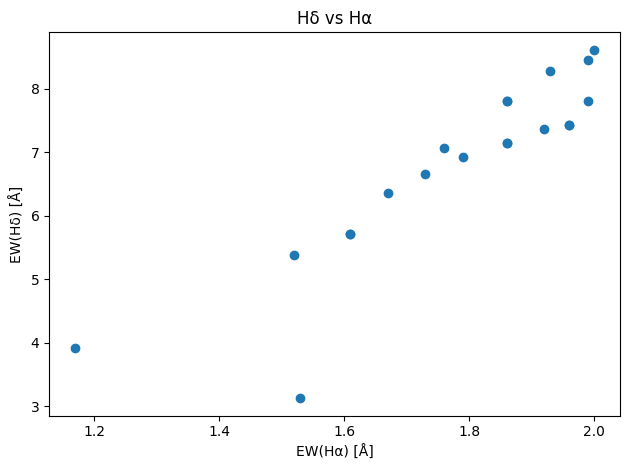

In [59]:

# --- Plot EW(Hδ) ---
plt.figure()
plt.scatter(ew_halpha[mask], ew_hdelta[mask], marker='o')
plt.xlabel("EW(Hα) [Å]")
plt.ylabel("EW(Hδ) [Å]")
plt.title("Hδ vs Hα")
plt.tight_layout()
plt.show()